In [1]:
import pandas as pd

df = pd.read_csv("../data/sales_data.csv")

df.head()

,OrderID,OrderDate,Product,Category,Region,Quantity,Price
0,1001,2024-01-05,Laptop,Electronics,North,2,800
1,1002,2024-01-06,Mouse,Electronics,South,5,20
2,1003,2024-01-07,Desk Chair,Furniture,West,1,150
3,1004,2024-01-08,Keyboard,Electronics,East,3,45
4,1005,2024-02-01,Laptop,Electronics,North,1,820


In [2]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

In [3]:
df.drop_duplicates(inplace=True)

df.isnull().sum()

OrderID      0
OrderDate    0
Product      0
Category     0
Region       0
Quantity     0
Price        0
dtype: int64

In [4]:
df["TotalSales"] = df["Quantity"] * df["Price"]

df["Year"] = df["OrderDate"].dt.year
df["Month"] = df["OrderDate"].dt.month

df.head()

,OrderID,OrderDate,Product,Category,Region,Quantity,Price,TotalSales,Year,Month
0,1001,2024-01-05,Laptop,Electronics,North,2,800,1600,2024,1
1,1002,2024-01-06,Mouse,Electronics,South,5,20,100,2024,1
2,1003,2024-01-07,Desk Chair,Furniture,West,1,150,150,2024,1
3,1004,2024-01-08,Keyboard,Electronics,East,3,45,135,2024,1
4,1005,2024-02-01,Laptop,Electronics,North,1,820,820,2024,2


In [5]:
total_revenue = df["TotalSales"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 4847


In [6]:
region_sales = df.groupby("Region")["TotalSales"].sum()

print(region_sales)

Region
East      365
North    3230
South     820
West      432
Name: TotalSales, dtype: int64


In [7]:
category_sales = df.groupby("Category")["TotalSales"].sum()

print(category_sales)

Category
Electronics    4045
Furniture       720
Stationery       82
Name: TotalSales, dtype: int64


In [8]:
top_products = df.groupby("Product")["TotalSales"].sum().sort_values(ascending=False)

print(top_products.head())

Product
Laptop        3230
Desk Chair     470
Monitor        400
Keyboard       315
Table          250
Name: TotalSales, dtype: int64


In [9]:
monthly_sales = df.groupby("Month")["TotalSales"].sum()

print(monthly_sales)

Month
1    1985
2    1302
3    1560
Name: TotalSales, dtype: int64


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

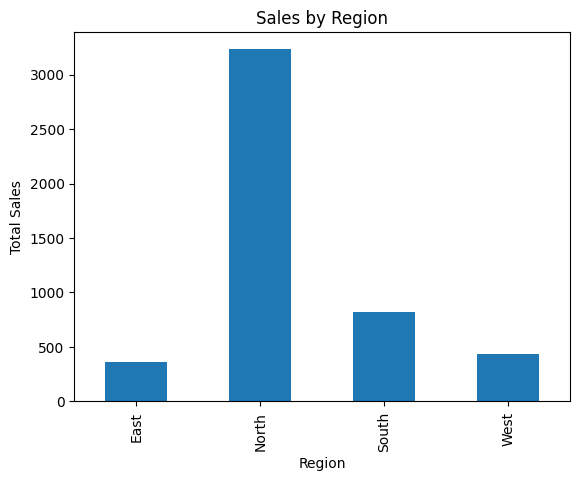

In [11]:
region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

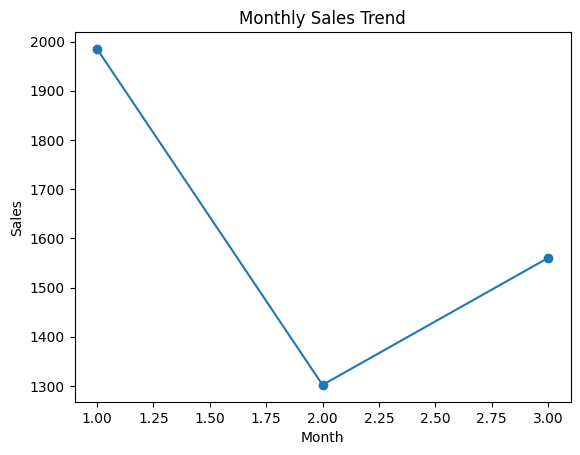

In [12]:
monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

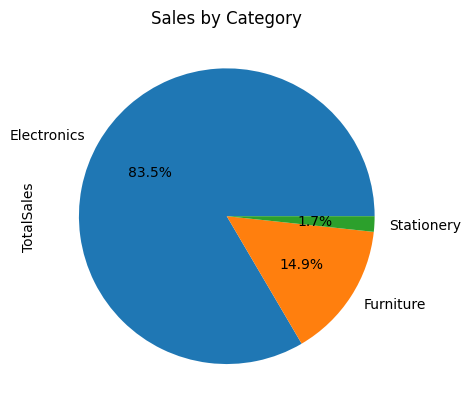

In [13]:
category_sales.plot(kind="pie", autopct='%1.1f%%')

plt.title("Sales by Category")

plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [15]:
X = df[["Month","Quantity","Price"]]

y = df["TotalSales"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [18]:
predictions = model.predict(X_test)

print(predictions[:5])

[105.885539   217.96811893 808.88754696]


In [19]:
mse = mean_squared_error(y_test, predictions)

print("Mean Squared Error:", mse)

Mean Squared Error: 213920.79047832286


In [20]:
future_data = pd.DataFrame({
    "Month":[4,5,6],
    "Quantity":[10,12,15],
    "Price":[200,200,200]
})

future_predictions = model.predict(future_data)

forecast_df = pd.DataFrame({
    "Month":["April","May","June"],
    "Predicted Sales": future_predictions
})

print(forecast_df)

   Month  Predicted Sales
0  April       215.837369
1    May       201.736281
2   June       183.600499


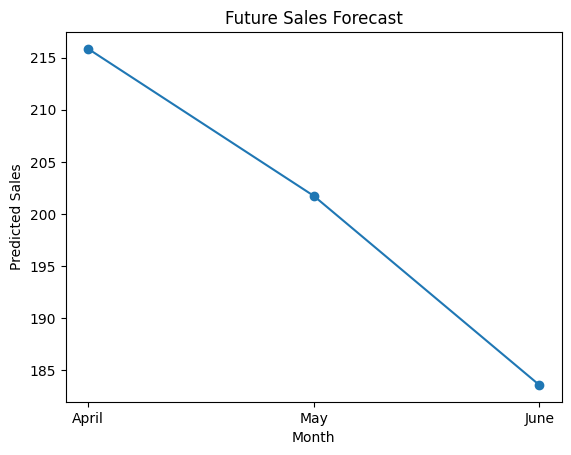

In [21]:
import matplotlib.pyplot as plt

plt.plot(forecast_df["Month"], forecast_df["Predicted Sales"], marker="o")

plt.title("Future Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Predicted Sales")

plt.show()